In [16]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [17]:
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print(f"Downloaded dataset to: {path}")

df = pd.read_csv(f"{path}/Salary_dataset.csv")
df.head()

Downloaded dataset to: /kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [18]:
def data_preproccessing(df): 
  if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

  df.drop_duplicates(inplace=True)

  df.dropna(inplace=True)

  print(f"Shape of DataFrame after preprocessing: {df.shape}")
  return df

df = data_preproccessing(df)
display(df.head())

Shape of DataFrame after preprocessing: (30, 2)


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df['YearsExperience'], df['Salary'], test_size=0.2, random_state=42
)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

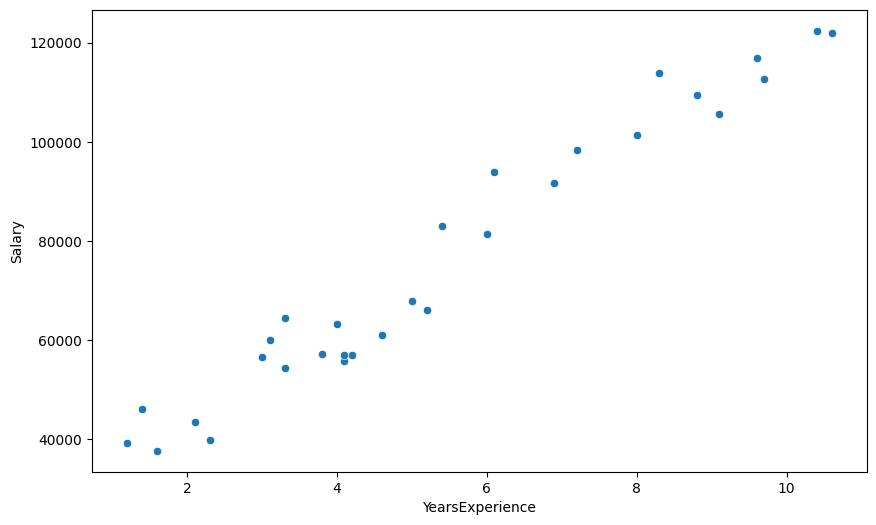

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt

In [21]:
model = LinearRegression()
model.fit(X_train.to_frame(), y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test.to_frame())

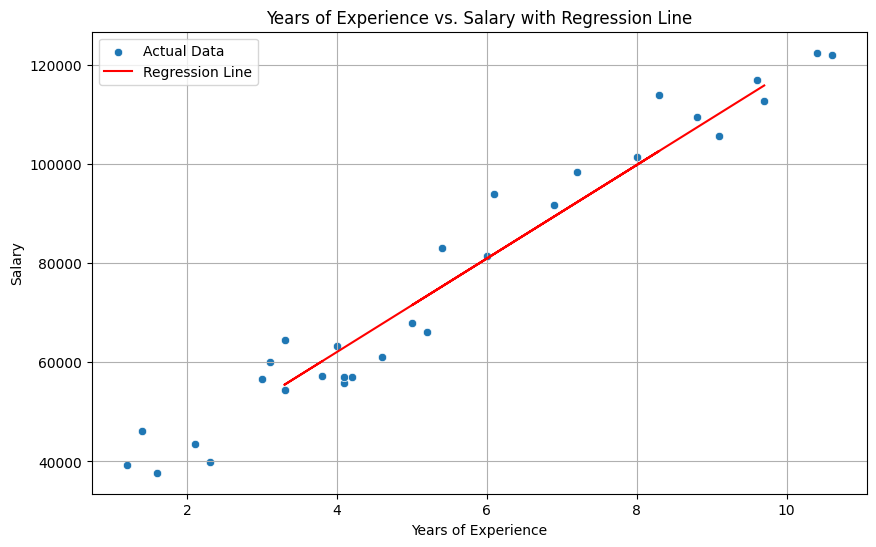

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.title('Years of Experience vs. Salary with Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

In [14]:

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 6286.45
R-squared: 0.90
